# Analisis Dataset

In [ ]:
#!pip install pillow-heif
#!pip install opencv-python

In [2]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pillow_heif
import shutil

### TAHAP 1: DATA CLEANING & PREPROCESSING (Hanya untuk Dataset Tambahan)

In [ ]:
pillow_heif.register_heif_opener()

sns.set_theme(style="whitegrid")

def clean_and_convert_heic_to_jpg(input_folder, output_folder):
    """
    Fungsi yang diperbarui: 
    - Mengonversi file HEIC menjadi JPG.
    - Menyalin langsung file yang sudah berformat JPG/JPEG/PNG ke folder tujuan.
    """
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
        
    print("===== Memulai Proses Data Cleaning & Sinkronisasi Folder =====")
    
    for class_name in os.listdir(input_folder):
        input_class_path = os.path.join(input_folder, class_name)
        
        if os.path.isdir(input_class_path):
            output_class_path = os.path.join(output_folder, class_name)
            if not os.path.exists(output_class_path):
                os.makedirs(output_class_path)
                
            all_files = os.listdir(input_class_path)
            
            count_heic = 0
            count_copied = 0
            
            for filename in all_files:
                file_path = os.path.join(input_class_path, filename)
                ext = filename.lower()
                
                if ext.endswith(('.heic', '.heif')):
                    jpg_filename = os.path.splitext(filename)[0] + ".jpg"
                    jpg_path = os.path.join(output_class_path, jpg_filename)
                    
                    try:
                        with Image.open(file_path) as img:
                            rgb_img = img.convert('RGB')
                            rgb_img.save(jpg_path, 'JPEG', quality=95)
                        count_heic += 1
                    except Exception as e:
                        print(f"  ❌ Gagal konversi {filename} di kelas {class_name}: {e}")
                
                elif ext.endswith(('.jpg', '.jpeg', '.png')):
                    destination_path = os.path.join(output_class_path, filename)
                    try:
                        shutil.copy2(file_path, destination_path)
                        count_copied += 1
                    except Exception as e:
                        print(f"  ❌ Gagal menyalin {filename} di kelas {class_name}: {e}")
            
            if count_heic > 0 or count_copied > 0:
                print(f"Kelas [{class_name}]: Berhasil mengonversi {count_heic} HEIC & menyalin {count_copied} gambar standar.")
                
    print("===== Data Cleaning Selesai! Seluruh data tambahan kini utuh di folder bersih =====\n")

In [4]:
#from google.colab import drive
#drive.mount('/content/drive')

### TAHAP 2: EKSTRAKSI KARAKTERISTIK DATASET (EDA)

In [ ]:
def analyze_dataset_folder(root_path, dataset_label):
    """
    Fungsi untuk mengekstrak metadata dari folder dataset citra yang sudah bersih (berformat JPG/PNG).
    """
    data_list = []

    if not os.path.exists(root_path):
        print(f"Peringatan: Path {root_path} tidak ditemukan.")
        return pd.DataFrame(data_list)

    for class_name in os.listdir(root_path):
        class_path = os.path.join(root_path, class_name)

        if os.path.isdir(class_path):
            images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

            for img_name in images:
                img_path = os.path.join(class_path, img_name)
                try:
                    with Image.open(img_path) as img:
                        width, height = img.size
                        mode = img.mode

                    data_list.append({
                        'Dataset': dataset_label,
                        'Kelas': class_name,
                        'Nama_File': img_name,
                        'Width': width,
                        'Height': height,
                        'Channels': 3 if mode == 'RGB' else (1 if mode == 'L' else 0),
                        'Aspect_Ratio': round(width / height, 2)
                    })
                except Exception as e:
                    print(f"Gagal membaca {img_path}: {e}")

    return pd.DataFrame(data_list)

In [ ]:
PATH_KAGGLE = "./Dataset_Rupiah_Emisi-2016(Kaggle)"
PATH_TAMBAHAN_MENTAH = "./Dataset Tambahan"
PATH_TAMBAHAN_BERSIH = "./Dataset-Tambahan-Bersih"

clean_and_convert_heic_to_jpg(PATH_TAMBAHAN_MENTAH, PATH_TAMBAHAN_BERSIH)

df_kaggle = analyze_dataset_folder(PATH_KAGGLE, "Kaggle (Utama)")
df_tambahan = analyze_dataset_folder(PATH_TAMBAHAN_BERSIH, "Tambahan (Bersih)")

df_all = pd.concat([df_kaggle, df_tambahan], ignore_index=True)
print(f"Total gambar gabungan yang siap dimodelkan: {len(df_all)} file.\n")

===== Memulai Proses Data Cleaning & Sinkronisasi Folder =====
Kelas [1000]: Berhasil mengonversi 9 HEIC & menyalin 42 gambar standar.
Kelas [10000]: Berhasil mengonversi 7 HEIC & menyalin 42 gambar standar.
Kelas [100000]: Berhasil mengonversi 7 HEIC & menyalin 42 gambar standar.
Kelas [2000]: Berhasil mengonversi 8 HEIC & menyalin 42 gambar standar.
Kelas [20000]: Berhasil mengonversi 30 HEIC & menyalin 12 gambar standar.
Kelas [5000]: Berhasil mengonversi 19 HEIC & menyalin 34 gambar standar.
Kelas [50000]: Berhasil mengonversi 11 HEIC & menyalin 44 gambar standar.
Kelas [Bukan Uang]: Berhasil mengonversi 115 HEIC & menyalin 311 gambar standar.
===== Data Cleaning Selesai! Seluruh data tambahan kini utuh di folder bersih =====

Total gambar gabungan yang siap dimodelkan: 3173 file.



### TAHAP 3: VISUALISASI HASIL ANALISIS DATA (REPORTING)

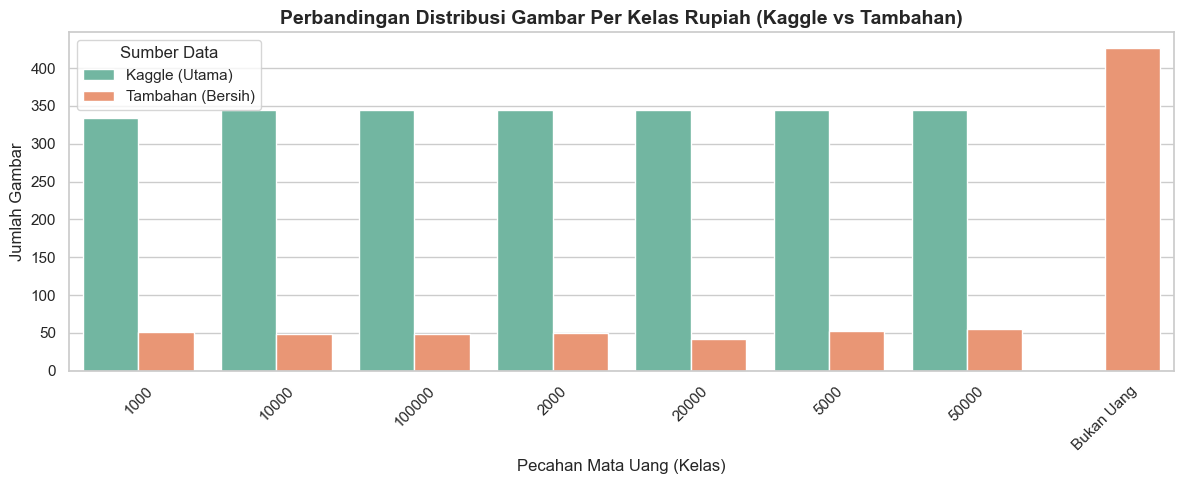

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df_all, x='Kelas', hue='Dataset', palette='Set2',
              order=sorted(df_all['Kelas'].unique()))
plt.title('Perbandingan Distribusi Gambar Per Kelas Rupiah (Kaggle vs Tambahan)', fontsize=14, fontweight='bold')
plt.xlabel('Pecahan Mata Uang (Kelas)')
plt.ylabel('Jumlah Gambar')
plt.xticks(rotation=45)
plt.legend(title='Sumber Data')
plt.tight_layout()
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_3396\3295252850.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df_all, x='Dataset', y='Aspect_Ratio', palette='Pastel1')


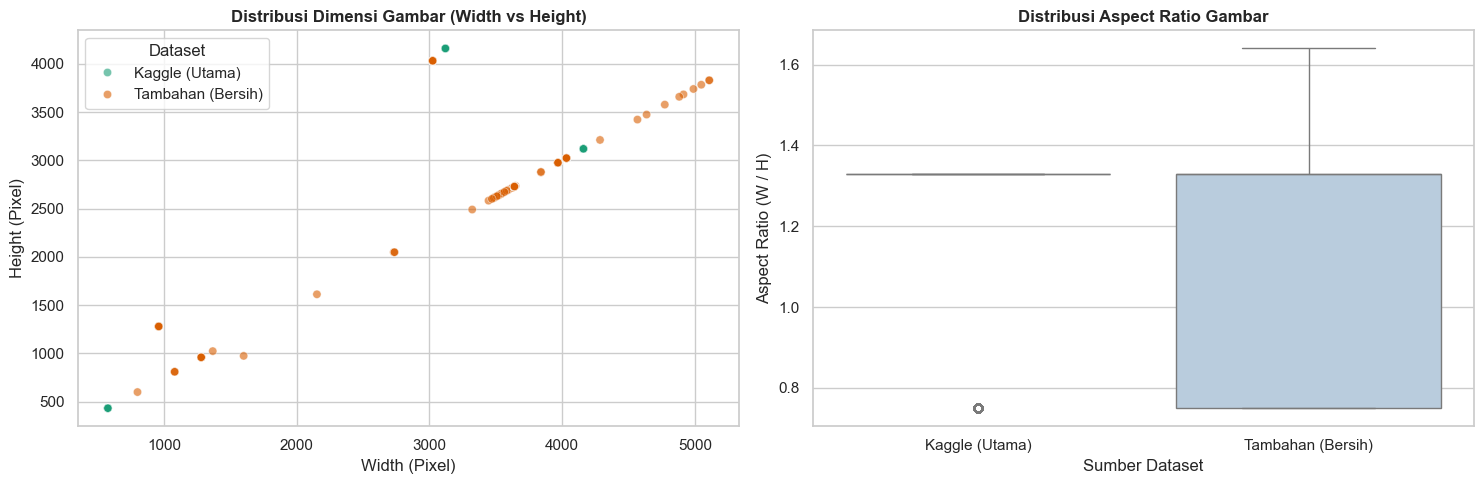

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(ax=axes[0], data=df_all, x='Width', y='Height', hue='Dataset', alpha=0.6, palette='Dark2')
axes[0].set_title('Distribusi Dimensi Gambar (Width vs Height)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Width (Pixel)')
axes[0].set_ylabel('Height (Pixel)')

sns.boxplot(ax=axes[1], data=df_all, x='Dataset', y='Aspect_Ratio', palette='Pastel1')
axes[1].set_title('Distribusi Aspect Ratio Gambar', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sumber Dataset')
axes[1].set_ylabel('Aspect Ratio (W / H)')
plt.tight_layout()
plt.show()

In [ ]:
print("--- Rangkuman Statistik Dataset Gabungan ---")
print(pd.crosstab(df_all['Kelas'], df_all['Dataset'], margins=True))

--- Rangkuman Statistik Dataset Gabungan ---
Dataset     Kaggle (Utama)  Tambahan (Bersih)   All
Kelas                                              
1000                   334                 51   385
10000                  344                 49   393
100000                 344                 49   393
2000                   344                 50   394
20000                  344                 42   386
5000                   344                 53   397
50000                  344                 55   399
Bukan Uang               0                426   426
All                   2398                775  3173


In [ ]:
print("--- Analisis Karakteristik Dimensi Gambar ---")
dimensi_summary = df_all.groupby('Dataset')[['Width', 'Height', 'Aspect_Ratio']].agg(['min', 'max', 'mean', 'median'])
display(dimensi_summary)

print("\n--- Analisis Kecenderungan Orientasi Gambar ---")
# Aspect Ratio > 1 artinya Landscape, < 1 artinya Portrait, == 1 artinya Square
df_all['Orientasi'] = np.where(df_all['Aspect_Ratio'] > 1.05, 'Landscape', 
                               np.where(df_all['Aspect_Ratio'] < 0.95, 'Portrait', 'Square'))

orientasi_summary = pd.crosstab(df_all['Orientasi'], df_all['Dataset'], normalize='columns') * 100
print(orientasi_summary.round(2).astype(str) + '%')

--- Analisis Karakteristik Dimensi Gambar ---


Width                            Height                     \
                    min   max         mean  median    min   max         mean   
Dataset                                                                        
Kaggle (Utama)      577  4160  1334.907840   577.0    433  4160  1246.514178   
Tambahan (Bersih)   800  5108  3298.054194  3968.0    600  4032  2904.305806   

                          Aspect_Ratio                         
                   median          min   max      mean median  
Dataset                                                        
Kaggle (Utama)      433.0         0.75  1.33  1.251877   1.33  
Tambahan (Bersih)  2976.0         0.75  1.64  1.138103   1.33


--- Analisis Kecenderungan Orientasi Gambar ---
Dataset   Kaggle (Utama) Tambahan (Bersih)
Orientasi                                 
Landscape         86.53%            66.84%
Portrait          13.47%            33.16%


### 📄 LAPORAN AKHIR RISET & ANALISIS DATASET GABUNGAN

Berikut adalah hasil analisis karakteristik data final dan rekomendasi teknis sebelum lanjut ke tahap berikutnya:

---

#### 1. Rangkuman Kuantitas & Distribusi Data Terbaru
Saat ini, total data bersih siap pakai kita melonjak menjadi **3.173 gambar** (gabungan Kaggle dan dataset tambahan), dengan rincian distribusi sebagai berikut:
* **Dataset Utama (Kaggle):** Total **2.398 gambar**. Distribusinya sangat seimbang (*perfectly balanced*) di angka 334–344 gambar per kelas nominal pecahan (Emisi 2016).
* **Dataset Tambahan (Foto HP Tim):** Total **775 gambar**.

---

#### 2. Analisis Karakteristik Dimensi & Orientasi Citra
Hasil ekstraksi visual menunjukkan adanya *gap* karakteristik geometris yang tetap harus kita mitigasi:
* **Dataset Kaggle:** Dominan berbentuk kotak (*Square*) atau persegi panjang horizontal (**Landscape**) dengan resolusi piksel kecil yang seragam.
* **Dataset Tambahan:** Dominan berbentuk tegak vertikal (**Portrait**) dengan resolusi piksel asli yang sangat tinggi (khas jepretan kamera *smartphone*).

---

### 🛠️ REKOMENDASI TEKNIS & PIPELINE PREPROCESSING

1. **Gunakan Teknik Resize with Padding / Letterboxing (Krusial):**
Mohon jangan langsung menggunakan fungsi `transforms.Resize((224, 224))` biasa. Karena 451 data tambahan kita dominan berbentuk **Portrait** sedangkan 2.398 data Kaggle berbentuk **Landscape**, *direct resize* akan memaksa gambar tegak ditarik melebar secara horizontal. Hal ini membuat fisik uang kertas terdistorsi (gepeng) dan merusak visual pola pahlawan/nominal uang yang harus dipelajari model.
* *Solusi:* Terapkan fungsi *padding* (tepian hitam/putih) untuk mempertahankan aspek rasio asli uang, baru skalanya dikecilkan ke ukuran input model.
2. **Standardisasi Skala Piksel (*Feature Scaling*):**
Mengingat adanya lonjakan resolusi piksel yang sangat jauh antara foto HP (sangat besar) dan dataset Kaggle (kecil), pastikan fungsi normalisasi nilai piksel ke rentang `0-1` (`transforms.ToTensor()` atau membagi matriks dengan 255.0) diaplikasikan secara merata di kedua sumber data untuk menjaga stabilitas konvergensi bobot model.
3. **Optimalisasi Augmentasi Data (*Data Augmentation*):**
Meskipun data tambahan kita sudah aman, rasionya masih lebih kecil dibanding dataset Kaggle. Oleh karena itu, ML Engineer wajib memperkuat augmentasi acak pada *training pipeline*, khususnya: **Rotasi Acak (*Random Rotation*)**, **Pergeseran Jendela (*Width/Height Shift*)**, dan **Manipulasi Pencahayaan (*Brightness/Contrast Adjustment*)**. Ini sangat penting karena kondisi pengambilan gambar nyata oleh pengunjung di area museum akan sangat bervariasi sudut dan intensitas cahayanya.

---

Folder dataset tambahan yang sudah melalui proses penyelarasan dan bersih berformat JPG (`Dataset-Tambahan-Bersih`) sudah siap digunakan untuk tahap selanjutnya (Preprocessing + Modeling).